Surface: 23 files found
  -> using cos(latitude)
100 m: 23 files found
  -> using cos(lat) for regular grid
200 m: 23 files found
  -> using cos(lat) for regular grid
300 m: 23 files found
  -> using cos(lat) for regular grid
400 m: 23 files found
  -> using cos(lat) for regular grid
500 m: 23 files found
  -> using cos(lat) for regular grid
Finished computing global means.
Available series: ['Surface', '100 m', '200 m', '300 m', '400 m', '500 m']
----------------------------------------------------------------------
Surface
  Min O2: 7.201 mg L-1
  Max O2: 7.721 mg L-1
  First below 4.6 mg L-1: None
  First below 2.0 mg L-1: None
100 m
  Min O2: 6.892 mg L-1
  Max O2: 7.395 mg L-1
  First below 4.6 mg L-1: None
  First below 2.0 mg L-1: None
200 m
  Min O2: 5.970 mg L-1
  Max O2: 6.310 mg L-1
  First below 4.6 mg L-1: None
  First below 2.0 mg L-1: None
300 m
  Min O2: 5.555 mg L-1
  Max O2: 5.785 mg L-1
  First below 4.6 mg L-1: None
  First below 2.0 mg L-1: None
400 m
  Min O2: 5.4

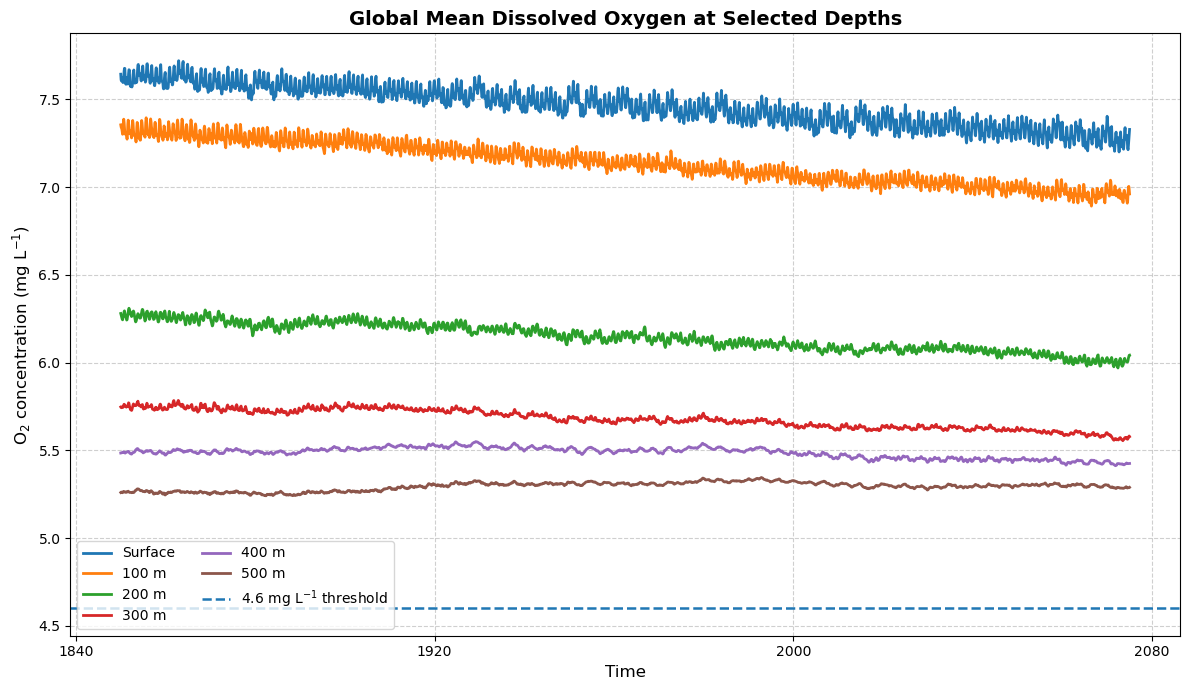

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

# label : file pattern
DEPTH_FILES = {
    "Surface": f"{BASE_DIR}/surface/o2_sfc_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "100 m":   f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "200 m":   f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "300 m":   f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "400 m":   f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "500 m":   f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
}

# Unit conversion
O2_MOLAR_MASS_G_MOL = 31.998
MOL_M3_TO_MG_L = O2_MOLAR_MASS_G_MOL

# Thresholds
THRESHOLD_SHALLOW = 4.6  # mg L-1
THRESHOLD_DEEP = 2.0     # mg L-1


# ============================================================
# Function: open files and compute global mean
# ============================================================

def compute_global_mean_o2(file_pattern, label):
    files = sorted(glob.glob(file_pattern))
    print(f"{label}: {len(files)} files found")

    if len(files) == 0:
        print(f"  -> skipped: no files found")
        return None

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    o2 = ds["o2"]

    # Remove lev if it remains
    if "lev" in o2.dims:
        o2 = o2.isel(lev=0, drop=True)

    # Convert mol m-3 to mg L-1
    o2_mgL = o2 * MOL_M3_TO_MG_L
    o2_mgL.attrs["units"] = "mg L-1"

    # Determine horizontal dimensions
    horizontal_dims = [dim for dim in o2_mgL.dims if dim not in ["time"]]

    # Area weights
    if "areacello" in ds:
        weights = ds["areacello"]
        print(f"  -> using areacello")
    elif ("lat" in ds.coords) and ("lon" in ds.coords):
        weights = np.cos(np.deg2rad(ds["lat"]))
        print(f"  -> using cos(lat) for regular grid")
    elif "latitude" in ds:
        lat = ds["latitude"].where(np.abs(ds["latitude"]) <= 90)
        weights = np.cos(np.deg2rad(lat))
        print(f"  -> using cos(latitude)")
    else:
        raise ValueError(f"No latitude information found for {label}")

    # Broadcast 1D lat weights to 2D automatically if needed
    ocean_mask = o2_mgL.isel(time=0).notnull()
    weights = weights.where(ocean_mask).fillna(0)

    # Weighted global mean
    gm = o2_mgL.weighted(weights).mean(
        dim=horizontal_dims,
        skipna=True
    ).compute()

    gm.name = label
    ds.close()

    return gm


# ============================================================
# Compute all depth means
# ============================================================

global_means = {}

for label, pattern in DEPTH_FILES.items():
    gm = compute_global_mean_o2(pattern, label)
    if gm is not None:
        global_means[label] = gm

print("Finished computing global means.")
print("Available series:", list(global_means.keys()))


# ============================================================
# Print summary and threshold crossing
# ============================================================

def find_first_below_time(da, threshold):
    mask = da < threshold
    if bool(mask.any().values):
        return da["time"].where(mask, drop=True).isel(time=0).values
    return None

print("-" * 70)

for label, da in global_means.items():
    min_val = float(da.min().values)
    max_val = float(da.max().values)

    first_4p6 = find_first_below_time(da, THRESHOLD_SHALLOW)
    first_2p0 = find_first_below_time(da, THRESHOLD_DEEP)

    print(f"{label}")
    print(f"  Min O2: {min_val:.3f} mg L-1")
    print(f"  Max O2: {max_val:.3f} mg L-1")
    print(f"  First below 4.6 mg L-1: {first_4p6}")
    print(f"  First below 2.0 mg L-1: {first_2p0}")

print("-" * 70)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(12, 7))

for label, da in global_means.items():
    da.plot(linewidth=2, label=label)

plt.axhline(
    THRESHOLD_SHALLOW,
    linestyle="--",
    linewidth=1.8,
    label="4.6 mg L$^{-1}$ threshold"
)

# plt.axhline(
#     THRESHOLD_DEEP,
#     linestyle=":",
#     linewidth=2.0,
#     label="2.0 mg L$^{-1}$ threshold"
# )

plt.title(
    "Global Mean Dissolved Oxygen at Selected Depths",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Time", fontsize=12)
plt.ylabel("O$_2$ concentration (mg L$^{-1}$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(ncol=2)
plt.tight_layout()

plt.savefig("global_mean_o2_selected_depths_mgL_with_thresholds.png", dpi=300)
plt.show()

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

DEPTH_FILES = {
    "Surface": f"{BASE_DIR}/surface_1x1/o2_sfc_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "100 m":   f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "200 m":   f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "300 m":   f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "400 m":   f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "500 m":   f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
}

THRESHOLD = 4.6
MIN_MONTHS = 12

# mol m-3 -> mg L-1
CONVERSION = 31.998

# ============================================================
# Critical year function
# ============================================================

def first_persistent_below_year(values, years, threshold=4.6, min_months=12):

    below = np.isfinite(values) & (values < threshold)

    count = 0

    for k, flag in enumerate(below):

        if flag:
            count += 1
        else:
            count = 0

        if count >= min_months:
            start_idx = k - min_months + 1
            return float(years[start_idx])

    return np.nan


# ============================================================
# Compute all depths
# ============================================================

critical_maps = {}

for depth_label, file_pattern in DEPTH_FILES.items():

    print(f"Processing {depth_label}")

    files = sorted(glob.glob(file_pattern))

    if len(files) == 0:
        print(f"  No files found.")
        continue

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1}
    )

    o2 = ds["o2"]

    if "lev" in o2.dims:
        o2 = o2.isel(lev=0, drop=True)

    o2_mgL = o2 * CONVERSION

    years = ds.time.dt.year.astype(np.int32)

    critical_year = xr.apply_ufunc(
        first_persistent_below_year,
        o2_mgL,
        years,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        kwargs={
            "threshold": THRESHOLD,
            "min_months": MIN_MONTHS,
        },
    )

    print("  Computing...")
    critical_maps[depth_label] = critical_year.compute()

    ds.close()


Processing Surface
  Computing...
Processing 100 m
  Computing...
Processing 200 m
  Computing...
Processing 300 m
  Computing...
Processing 400 m
  Computing...
Processing 500 m
  Computing...


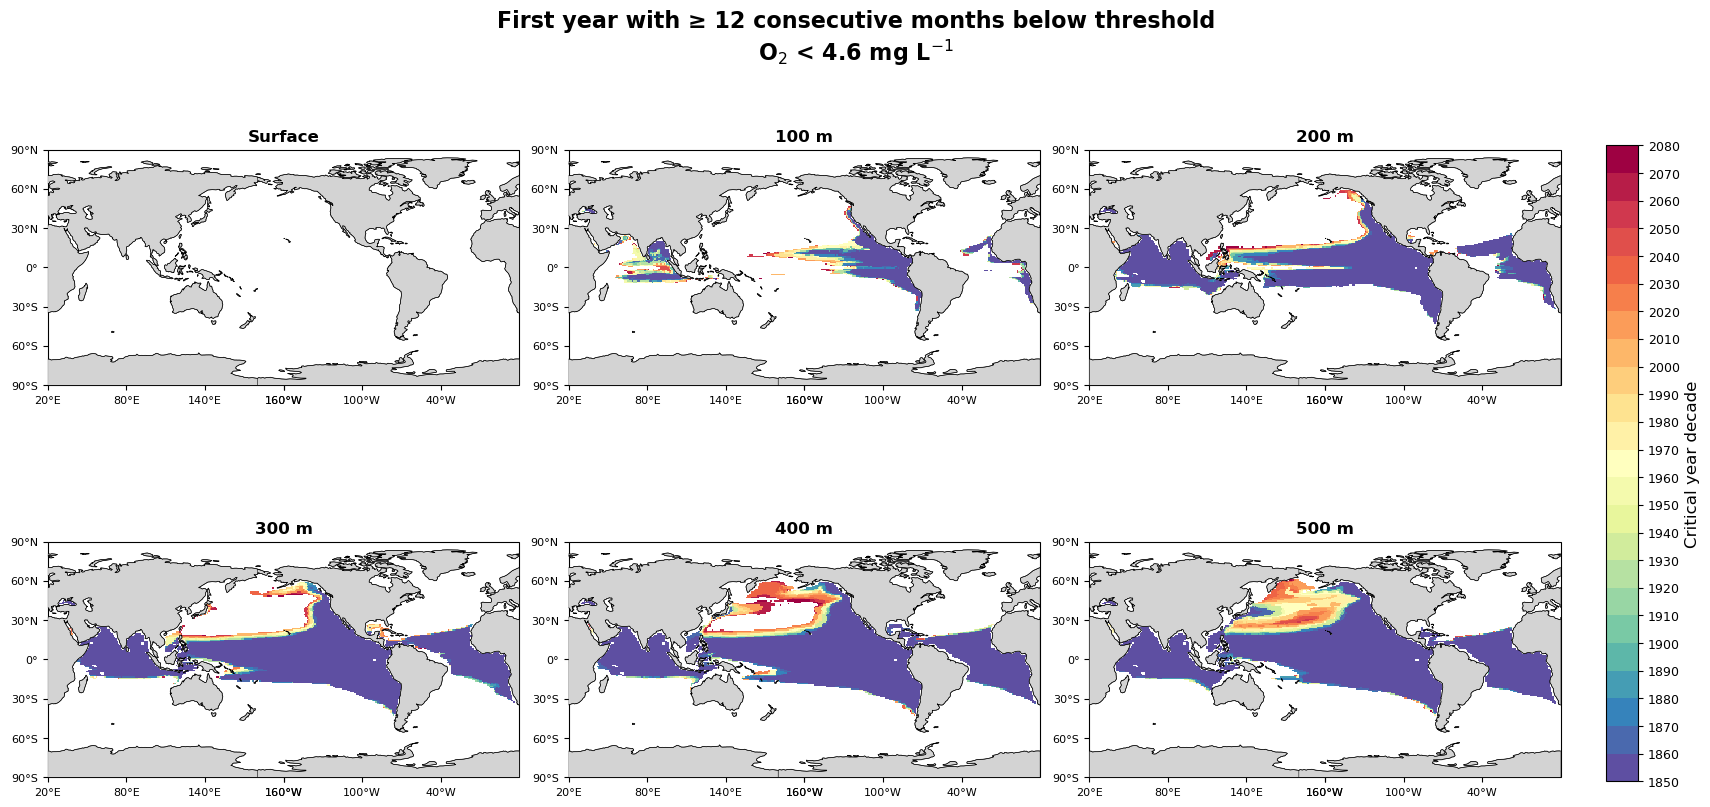

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import warnings

warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Discrete 10-year colorbar
# ============================================================

all_values = np.concatenate([
    da.values[np.isfinite(da.values)]
    for da in critical_maps.values()
])

start_decade = int(np.floor(np.nanmin(all_values) / 10) * 10)
end_decade = int(np.ceil(np.nanmax(all_values) / 10) * 10)
bounds = np.arange(start_decade, end_decade + 10, 10)

cmap = plt.get_cmap("Spectral_r", len(bounds) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(bounds, cmap.N)

# ============================================================
# Projection: center longitude at 200E
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 8.5),
    subplot_kw={"projection": map_crs},
    constrained_layout=True
)

axes = axes.flatten()

for ax, (depth_label, critical_year) in zip(axes, critical_maps.items()):

    pcm = critical_year.plot(
        ax=ax,
        x="lon",
        y="lat",
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10
    )
    ax.coastlines(resolution="110m", linewidth=0.5, zorder=11)

    ax.set_global()

    ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(depth_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

cbar = fig.colorbar(
    pcm,
    ax=axes,
    boundaries=bounds,
    ticks=bounds,
    spacing="proportional",
    shrink=0.82,
    pad=0.03
)

cbar.set_label("Critical year decade", fontsize=12)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    f"First year with ≥ {MIN_MONTHS} consecutive months below threshold\n"
    f"O$_2$ < {THRESHOLD} mg L$^{{-1}}$",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    f"critical_year_O2_{THRESHOLD}mgL_{MIN_MONTHS}months_depth_panels_center200E.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Computing global mean CO2...
CO2: 23 files found
Computing global mean O2 at selected depths...
Surface: 23 files found
100 m: 23 files found
200 m: 23 files found
300 m: 23 files found
400 m: 23 files found
500 m: 23 files found
Available O2 series: ['Surface', '100 m', '200 m', '300 m', '400 m', '500 m']


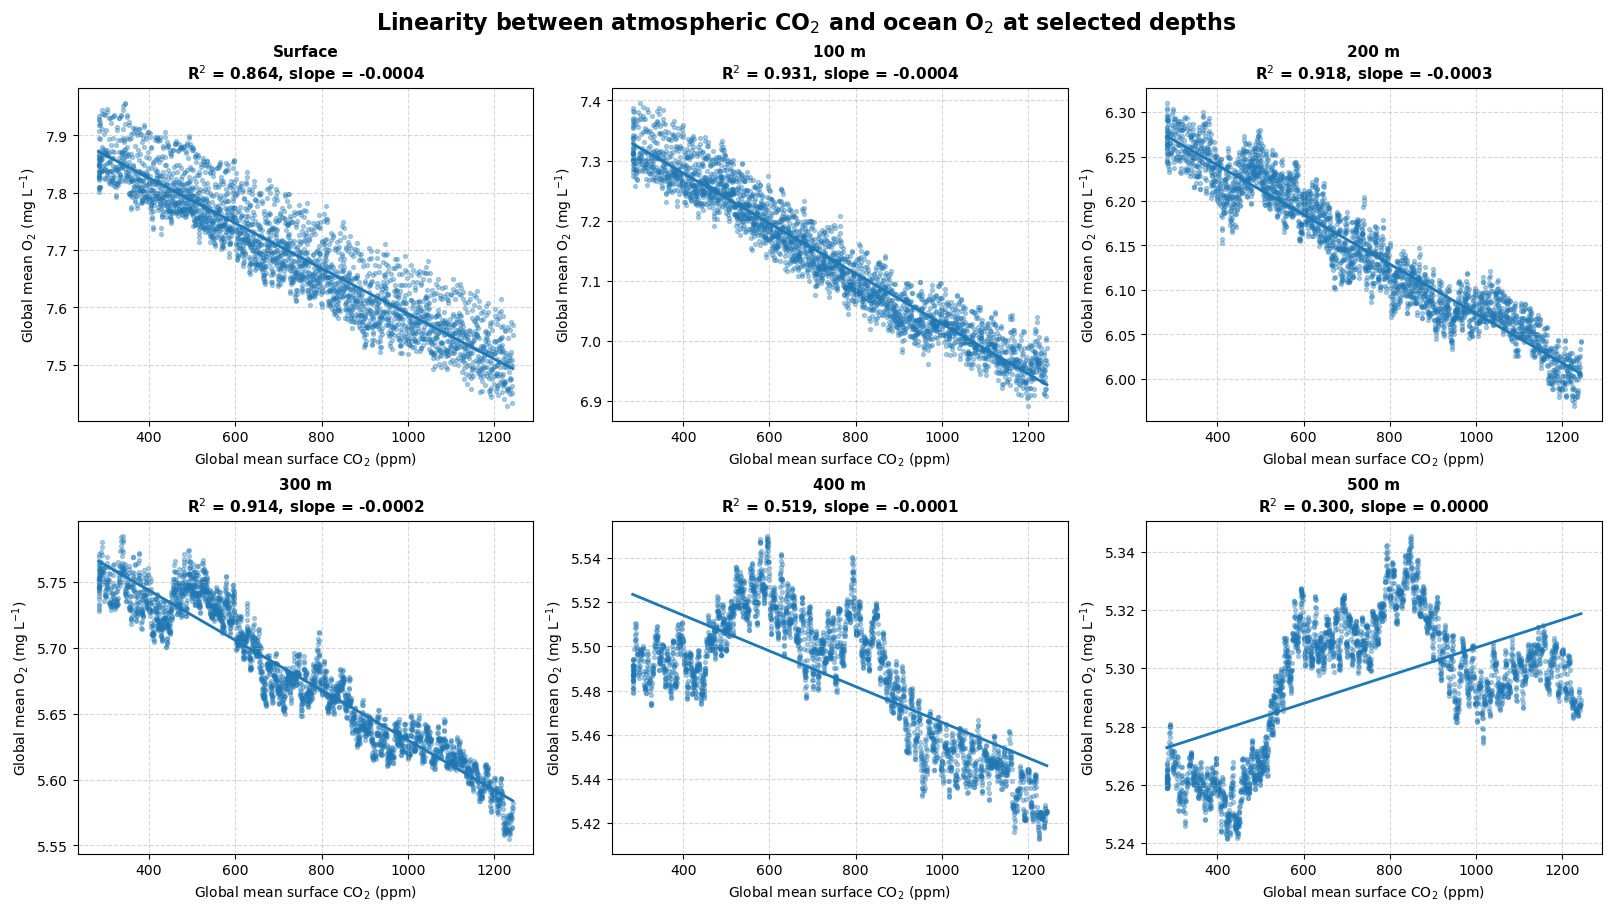

--------------------------------------------------------------------------------
Linear regression summary: O2 = slope × CO2 + intercept
--------------------------------------------------------------------------------
Surface  | n =  2700 | slope = -0.000394 mg L-1 ppm-1 | R2 = 0.8642
100 m    | n =  2700 | slope = -0.000417 mg L-1 ppm-1 | R2 = 0.9309
200 m    | n =  2700 | slope = -0.000278 mg L-1 ppm-1 | R2 = 0.9177
300 m    | n =  2700 | slope = -0.000189 mg L-1 ppm-1 | R2 = 0.9141
400 m    | n =  2700 | slope = -0.000081 mg L-1 ppm-1 | R2 = 0.5195
500 m    | n =  2700 | slope = 0.000048 mg L-1 ppm-1 | R2 = 0.2996


In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

O2_PATTERNS = {
    "Surface": f"{BASE_DIR}/surface_1x1/o2_sfc_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "100 m":   f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "200 m":   f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "300 m":   f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "400 m":   f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    "500 m":   f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
}

O2_CONVERSION = 31.998  # mol m-3 -> mg L-1


# ============================================================
# Function: compute global mean CO2 ppm
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):
    files = sorted(glob.glob(file_pattern))
    print(f"CO2: {len(files)} files found")

    if len(files) == 0:
        raise FileNotFoundError("No CO2 files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    # Surface pressure level
    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"]))
    weights = weights.fillna(0)

    co2_gm = co2.weighted(weights).mean(dim=["lat", "lon"], skipna=True)

    # mol mol-1 -> ppm
    co2_ppm = (co2_gm * 1e6).compute()
    co2_ppm.name = "CO2_ppm"

    ds.close()

    return co2_ppm


# ============================================================
# Function: compute global mean O2 mg L-1
# ============================================================

def compute_global_mean_o2_mgL(file_pattern, label):
    files = sorted(glob.glob(file_pattern))
    print(f"{label}: {len(files)} files found")

    if len(files) == 0:
        return None

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    o2 = ds["o2"]

    if "lev" in o2.dims:
        o2 = o2.isel(lev=0, drop=True)

    o2_mgL = o2 * O2_CONVERSION
    o2_mgL.attrs["units"] = "mg L-1"

    # 1x1 regular grid case
    if ("lat" in ds.coords) and ("lon" in ds.coords):
        weights = np.cos(np.deg2rad(ds["lat"]))
        spatial_dims = ["lat", "lon"]
    else:
        lat = ds["latitude"].where(np.abs(ds["latitude"]) <= 90)
        weights = np.cos(np.deg2rad(lat))
        spatial_dims = ["j", "i"]

    ocean_mask = o2_mgL.isel(time=0).notnull()
    weights = weights.where(ocean_mask).fillna(0)

    o2_gm = o2_mgL.weighted(weights).mean(
        dim=spatial_dims,
        skipna=True
    ).compute()

    o2_gm.name = label

    ds.close()

    return o2_gm


# ============================================================
# Compute CO2 and O2 global means
# ============================================================

print("Computing global mean CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

print("Computing global mean O2 at selected depths...")
o2_depth_series = {}

for label, pattern in O2_PATTERNS.items():
    da = compute_global_mean_o2_mgL(pattern, label)
    if da is not None:
        o2_depth_series[label] = da

print("Available O2 series:", list(o2_depth_series.keys()))


# ============================================================
# Linear relationship: O2 vs CO2
# ============================================================

fit_results = {}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
    constrained_layout=True
)

axes = axes.flatten()

for ax, (label, o2_da) in zip(axes, o2_depth_series.items()):

    # Align monthly time series
    co2_aligned, o2_aligned = xr.align(co2_ppm, o2_da, join="inner")

    x = co2_aligned.values
    y = o2_aligned.values

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # Linear regression
    reg = linregress(x, y)
    y_fit = reg.slope * x + reg.intercept
    r2 = reg.rvalue ** 2

    fit_results[label] = {
        "slope": reg.slope,
        "intercept": reg.intercept,
        "r2": r2,
        "pvalue": reg.pvalue,
        "stderr": reg.stderr,
        "n": len(x),
    }

    # Sort for clean line
    idx = np.argsort(x)

    ax.scatter(x, y, s=8, alpha=0.35)
    ax.plot(x[idx], y_fit[idx], linewidth=2)

    ax.set_title(
        f"{label}\nR$^2$ = {r2:.3f}, slope = {reg.slope:.4f}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Global mean surface CO$_2$ (ppm)")
    ax.set_ylabel("Global mean O$_2$ (mg L$^{-1}$)")
    ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle(
    "Linearity between atmospheric CO$_2$ and ocean O$_2$ at selected depths",
    fontsize=16,
    fontweight="bold"
)

plt.savefig("linear_relationship_CO2_vs_O2_selected_depths.png", dpi=300)
plt.show()


# ============================================================
# Print regression summary
# ============================================================

print("-" * 80)
print("Linear regression summary: O2 = slope × CO2 + intercept")
print("-" * 80)

for label, res in fit_results.items():
    print(
        f"{label:8s} | "
        f"n = {res['n']:5d} | "
        f"slope = {res['slope']:.6f} mg L-1 ppm-1 | "
        f"R2 = {res['r2']:.4f}"
    )

In [5]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

DEPTH_FILES = {
    "100 m": f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_*.nc",
    "200 m": f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_*.nc",
    "300 m": f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_*.nc",
    "400 m": f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_*.nc",
    "500 m": f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_*.nc",
}

O2_CONVERSION = 31.998  # mol m-3 -> mg L-1

# ============================================================
# Functions
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):
    files = sorted(glob.glob(file_pattern))
    print(f"CO2: {len(files)} files found")

    if len(files) == 0:
        raise FileNotFoundError("No CO2 files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"])).fillna(0)

    co2_ppm = (
        co2.weighted(weights)
        .mean(dim=["lat", "lon"], skipna=True)
        * 1e6
    ).compute()

    ds.close()

    return co2_ppm


def r2_1d(x, y):
    """
    R2 of linear regression y = a*x + b.
    """
    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 24:
        return np.nan

    xx = x[valid]
    yy = y[valid]

    if np.nanstd(xx) == 0 or np.nanstd(yy) == 0:
        return np.nan

    r = np.corrcoef(xx, yy)[0, 1]

    return r ** 2


# ============================================================
# Compute CO2
# ============================================================

print("Computing global mean CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

# ============================================================
# Compute R2 maps
# ============================================================

r2_maps = {}

for depth_label, file_pattern in DEPTH_FILES.items():

    print(f"Processing {depth_label}")

    files = sorted(glob.glob(file_pattern))
    print(f"  {len(files)} files found")

    if len(files) == 0:
        print("  skipped")
        continue

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1}
    )

    o2 = ds["o2"]

    if "lev" in o2.dims:
        o2 = o2.isel(lev=0, drop=True)

    o2_mgL = o2 * O2_CONVERSION

    # Align time between CO2 and O2
    co2_aligned, o2_aligned = xr.align(
        co2_ppm,
        o2_mgL,
        join="inner"
    )

    r2_map = xr.apply_ufunc(
        r2_1d,
        co2_aligned,
        o2_aligned,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
    )

    print("  Computing R2 map...")
    r2_maps[depth_label] = r2_map.compute()

    ds.close()

print("Done.")

Computing global mean CO2...
CO2: 23 files found
Processing 100 m
  23 files found
  Computing R2 map...
Processing 200 m
  23 files found
  Computing R2 map...
Processing 300 m
  23 files found
  Computing R2 map...
Processing 400 m
  23 files found
  Computing R2 map...
Processing 500 m
  23 files found
  Computing R2 map...
Done.


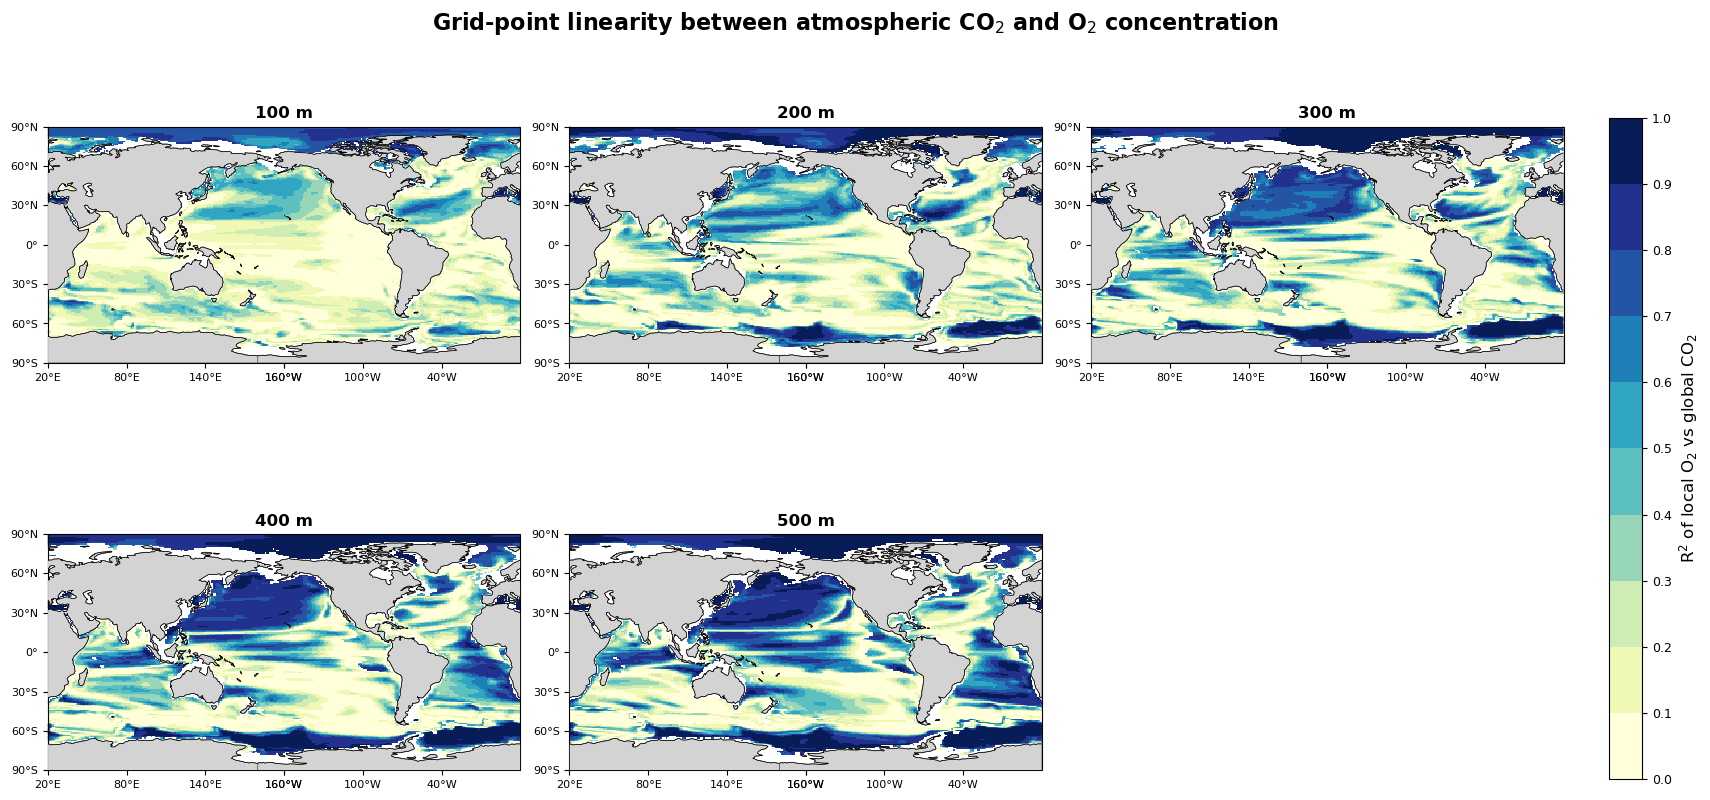

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import warnings

warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Color settings
# ============================================================

levels = np.linspace(0, 1, 11)

cmap = plt.get_cmap("YlGnBu", len(levels) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

# ============================================================
# Map projection
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 8.5),
    subplot_kw={"projection": map_crs},
    constrained_layout=True
)

axes = axes.flatten()

for ax, (depth_label, r2_map) in zip(axes, r2_maps.items()):

    pcm = r2_map.plot(
        ax=ax,
        x="lon",
        y="lat",
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10
    )

    ax.coastlines(resolution="110m", linewidth=0.5, zorder=11)

    ax.set_global()

    ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(depth_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

# Hide unused panel
for ax in axes[len(r2_maps):]:
    ax.set_visible(False)

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    boundaries=levels,
    ticks=levels,
    spacing="proportional",
    shrink=0.82,
    pad=0.03
)

cbar.set_label("R$^2$ of local O$_2$ vs global CO$_2$", fontsize=12)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Grid-point linearity between atmospheric CO$_2$ and O$_2$ concentration",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "R2_map_CO2_vs_O2_concentration_100m_500m.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

depth_info = {
    "Surface": (
        f"{BASE_DIR}/surface_1x1/"
        "o2_sfc_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
    ),
    "100 m": (
        f"{BASE_DIR}/depth_100m_1x1/"
        "o2_100m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
    ),
    "200 m": (
        f"{BASE_DIR}/depth_200m_1x1/"
        "o2_200m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
    ),
    "300 m": (
        f"{BASE_DIR}/depth_300m_1x1/"
        "o2_300m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
    ),
    "500 m": (
        f"{BASE_DIR}/depth_500m_1x1/"
        "o2_500m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
    ),
    "800 m": (
        f"{BASE_DIR}/depth_800m_1x1/"
        "o2_800m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
    ),
}

O2_MOLAR_MASS_G_MOL = 31.998

# ============================================================
# Functions
# ============================================================

def linear_trend_1d(values, years):
    valid = np.isfinite(values) & np.isfinite(years)

    if valid.sum() < 24:
        return np.nan

    x = years[valid]
    y = values[valid]

    slope = np.polyfit(x, y, 1)[0]

    return slope * 100.0


def compute_o2_trend_map(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"Files: {len(files)}")

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {file_pattern}")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1}
    )

    o2 = ds["o2"] * O2_MOLAR_MASS_G_MOL
    o2.name = "o2_mg_L"

    years = xr.DataArray(
        np.array([
            t.year + (t.month - 0.5) / 12.0
            for t in o2["time"].values
        ]),
        dims="time",
        coords={"time": o2["time"]}
    )

    trend = xr.apply_ufunc(
        linear_trend_1d,
        o2,
        years,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    trend = trend.compute()
    trend.name = "o2_trend_mg_L_per_century"
    trend.attrs["units"] = "mg L-1 century-1"

    ds.close()

    return trend

# ============================================================
# Compute trend maps
# ============================================================

trend_maps = {}

for depth_label, pattern in depth_info.items():
    print("=" * 80)
    print(depth_label)

    trend_maps[depth_label] = compute_o2_trend_map(pattern)

print("Done.")

Surface
Files: 23


ValueError: dimension time on 0th function argument to apply_ufunc with dask='parallelized' consists of multiple chunks, but is also a core dimension. To fix, either rechunk into a single array chunk along this dimension, i.e., ``.chunk(dict(time=-1))``, or pass ``allow_rechunk=True`` in ``dask_gufunc_kwargs`` but beware that this may significantly increase memory usage.